# RFM + КОГОРТНЫЙ АНАЛИЗ + ABC-XYZ + АНАЛИЗ КОРЗИН
# Датасет: Online Retail

# Загрузка библиотек и датасета

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanlian/online-retail-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-dataset' dataset.
Path to dataset files: /kaggle/input/online-retail-dataset


In [ ]:
df_0910 = pd.read_excel('/kaggle/input/online-retail-dataset/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_1011 = pd.read_excel('/kaggle/input/online-retail-dataset/online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df_0910, df_1011], ignore_index=True)

print(f"Загружено строк: {len(df)}")

Загружено строк: 1067371


Очистка данных

In [ ]:
# Удаляю строки без Customer ID
before = len(df)
df = df.dropna(subset=['Customer ID'])

# Убираю возвраты (Invoice с 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Убираю отрицательные/нулевые количества и цены
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Создаю сумму покупки
df['TotalAmount'] = df['Quantity'] * df['Price']

print(f"Удалено строк: {before - len(df)}")

Удалено строк: 261822


In [ ]:
print(f"Итоговое количество строк: {len(df)}")
print(f"Уникальных клиентов: {df['Customer ID'].nunique()}")
print(f"Период: с {df['InvoiceDate'].min()} по {df['InvoiceDate'].max()}")

Итоговое количество строк: 805549
Уникальных клиентов: 5878
Период: с 2009-12-01 07:45:00 по 2011-12-09 12:50:00


## RFM-СЕГМЕНТАЦИЯ

In [ ]:
last_date = df['InvoiceDate'].max()

In [ ]:
# Группировка по клиенту
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (last_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                 # Frequency
    'TotalAmount': 'sum'                                  # Monetary
}).reset_index()

In [ ]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [ ]:
# БАллы RFM
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])   # чем меньше Recency, тем выше балл
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])

Суммарный балл и сегмент

In [ ]:
rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

In [ ]:
def get_segment(score):
    if score >= 11:
        return 'VIP'
    elif score >= 8:
        return 'Loyal'
    elif score >= 5:
        return 'Regular'
    elif score >= 3:
        return 'Sleeping'

In [ ]:
rfm['Segment'] = rfm['RFM_score'].apply(get_segment)

Распределение клиентов по сегментам:

In [ ]:
print(rfm['Segment'].value_counts())

Segment
Regular     1803
Loyal       1746
VIP         1182
Sleeping    1147
Name: count, dtype: int64


Визуализация:

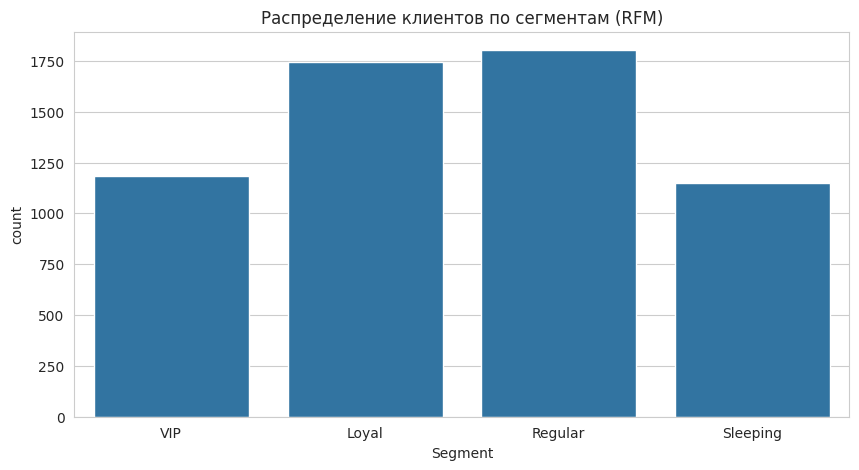

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=rfm, x='Segment', order=['VIP', 'Loyal', 'Regular', 'Sleeping'])
plt.title('Распределение клиентов по сегментам (RFM)')
plt.show()

Доля выручки по сегментам:

In [ ]:
for seg in rfm['Segment'].unique():
    revenue_pct = rfm[rfm['Segment'] == seg]['Monetary'].sum() / rfm['Monetary'].sum() * 100
    print(f"{seg}: {revenue_pct:.1f}%")

Loyal: 22.3%
VIP: 69.3%
Sleeping: 1.5%
Regular: 7.0%


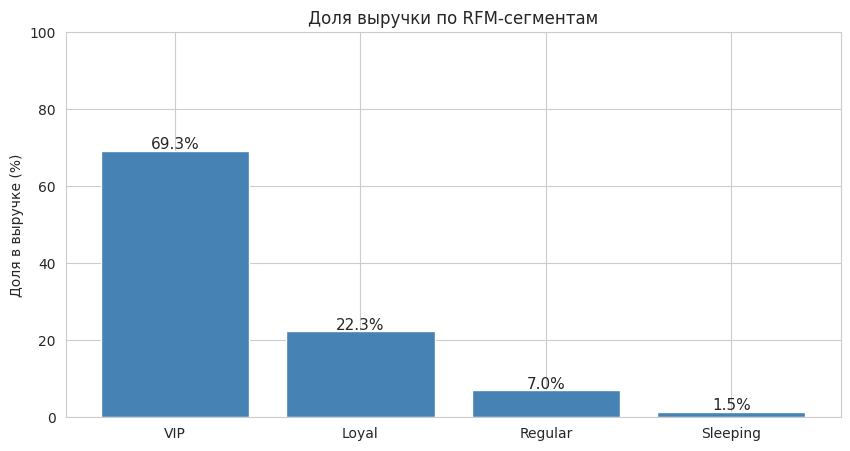

In [ ]:
# Доля выручки по сегментам
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum()
revenue_by_segment = revenue_by_segment / revenue_by_segment.sum() * 100

# порядок сегментов
order = ['VIP', 'Loyal', 'Regular', 'Sleeping']
revenue_by_segment = revenue_by_segment.reindex(order)

plt.figure(figsize=(10, 5))
bars = plt.bar(revenue_by_segment.index, revenue_by_segment.values, color='steelblue')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=11)

plt.ylabel('Доля в выручке (%)')
plt.title('Доля выручки по RFM-сегментам')
plt.ylim(0, 100)
plt.show()

VIP-сегмент (20% клиентов) генерирует 69% выручки.
Рекомендуется: персональные предложения и программа лояльности.
Sleeping-сегмент (20% клиентов) — триггерная кампания для реактивации.

ХАРАКТЕРИСТИКИ СЕГМЕНТОВ

In [47]:
for seg in ['VIP', 'Loyal', 'Regular', 'Sleeping']:
    subset = rfm[rfm['Segment'] == seg]
    print(f"\n{seg}:")
    print(f"  - Клиентов: {len(subset)}")
    print(f"  - Средний Recency: {subset['Recency'].mean():.0f} дней")
    print(f"  - Средняя частота: {subset['Frequency'].mean():.1f} покупок")
    print(f"  - Средний чек: ${subset['Monetary'].mean():.0f}")


VIP:
  - Клиентов: 1182
  - Средний Recency: 22 дней
  - Средняя частота: 18.7 покупок
  - Средний чек: $10397

Loyal:
  - Клиентов: 1746
  - Средний Recency: 101 дней
  - Средняя частота: 5.5 покупок
  - Средний чек: $2267

Regular:
  - Клиентов: 1803
  - Средний Recency: 241 дней
  - Средняя частота: 2.2 покупок
  - Средний чек: $685

Sleeping:
  - Клиентов: 1147
  - Средний Recency: 472 дней
  - Средняя частота: 1.1 покупок
  - Средний чек: $228


## КОГОРТНЫЙ АНАЛИЗ (RETENTION)

In [ ]:
df_clear = df.copy()

In [ ]:
df = df_clear.copy()

In [ ]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Месяц первой покупки для каждого клиента
first_purchase = df.groupby('Customer ID')['InvoiceMonth'].min().rename('Cohort')
df = df.merge(first_purchase, on='Customer ID', how='left')
df = df.dropna(subset=['Cohort'])

# Группировка: когорта, месяц покупки, количество уникальных клиентов
cohort_data = df.groupby(['Cohort', 'InvoiceMonth'])['Customer ID'].nunique().reset_index()
cohort_data.rename(columns={'Customer ID': 'Customers'}, inplace=True)

In [ ]:
# Создаю номера периодов
df['CohortMonth'] = pd.to_datetime(df['Cohort']).dt.to_period('M')
df['OrderMonth'] = pd.to_datetime(df['InvoiceMonth']).dt.to_period('M')
df['PeriodNum'] = (df['OrderMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + (df['OrderMonth'].dt.month - df['CohortMonth'].dt.month)

# Группирую
cohort_data = df.groupby(['Cohort', 'PeriodNum'])['Customer ID'].nunique().reset_index()
cohort_data.columns = ['Cohort', 'PeriodNum', 'Customers']

# Строю таблицу
cohort_pivot = cohort_data.pivot(index='Cohort', columns='PeriodNum', values='Customers').fillna(0)

# Retention
cohort_pivot = cohort_pivot.div(cohort_pivot[0], axis=0) * 100
cohort_pivot = cohort_pivot.fillna(0).replace([np.inf, -np.inf], 0)

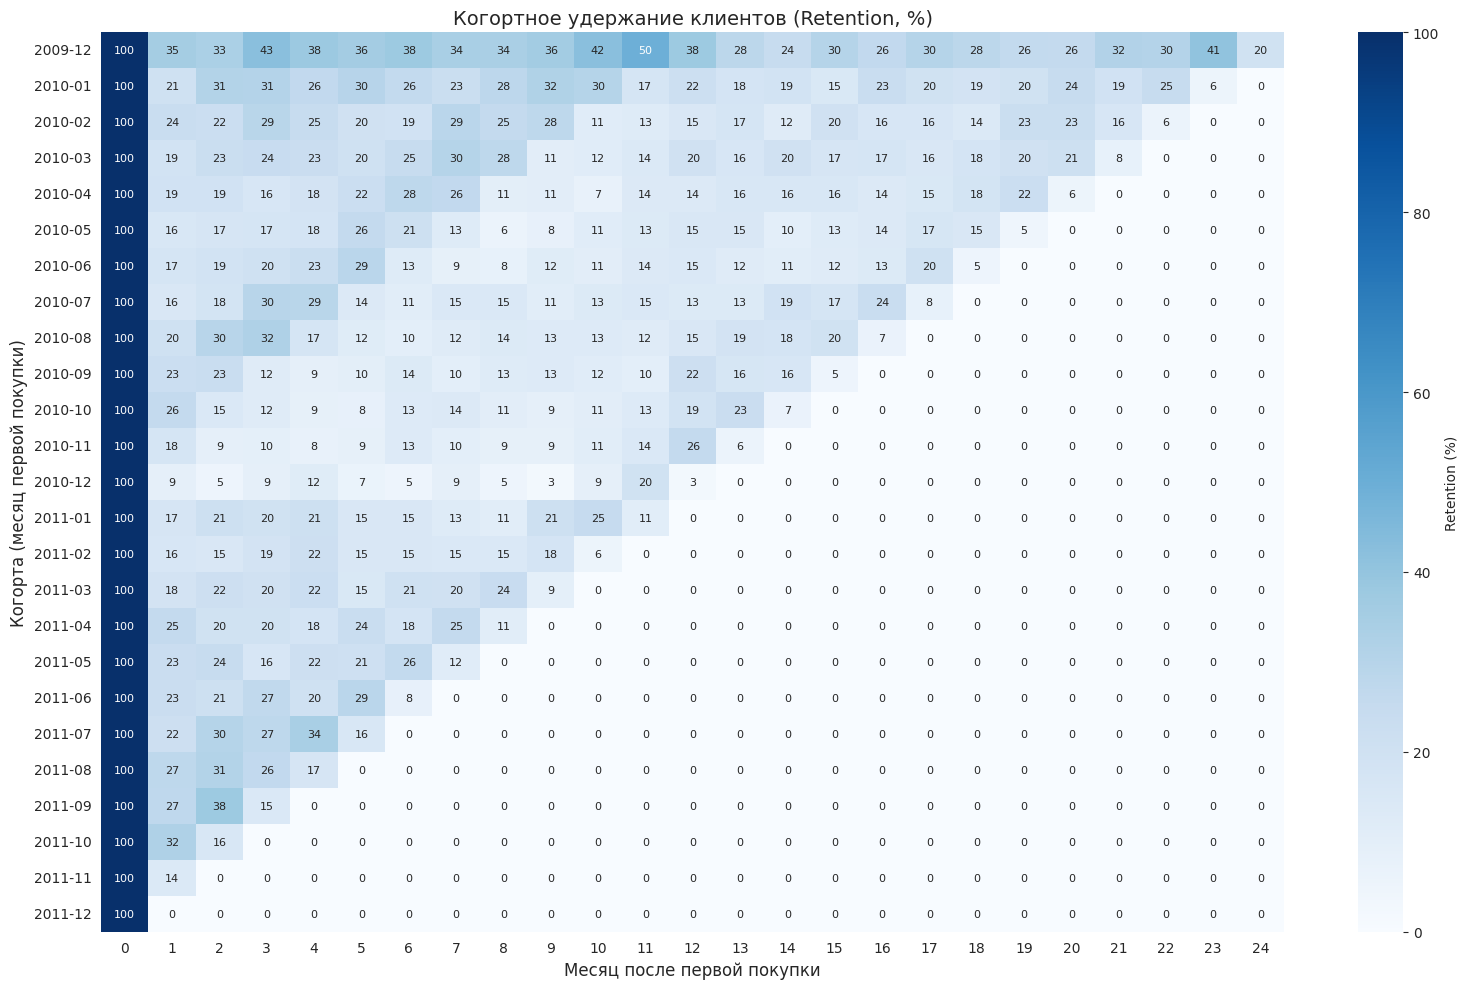

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Retention (%)'},
            annot_kws={'size': 8})
plt.title('Когортное удержание клиентов (Retention, %)', fontsize=14)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=12)
plt.xlabel('Месяц после первой покупки', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Удержание резко падает после 1-го месяца (средний retention на 2-й месяц — 24%).
Когорта декабрь 2010 показывает аномально низкое удержание — рекомендуется анализ причин (сезонность, логистика, качество обслуживания).
Также имеется сезонность – большее количество клиентов возвращается в ноябре.

СРЕДНЕЕ УДЕРЖАНИЕ ПО МЕСЯЦАМ

In [48]:
# Средний retention по месяцам
avg_retention = cohort_pivot.mean(axis=0)
for month in range(1, min(6, len(avg_retention))):
    print(f"Месяц {month}: {avg_retention[month]:.1f}%")

# Лучшая и худшая когорта
if cohort_pivot.shape[1] > 1:
    best_cohort = cohort_pivot.iloc[:, 1].idxmax()
    worst_cohort = cohort_pivot.iloc[:, 1].idxmin()
    print(f"\nЛучшая когорта по retention на 2-й месяц: {best_cohort}")
    print(f"Худшая когорта: {worst_cohort}")

Месяц 1: 20.3%
Месяц 2: 20.2%
Месяц 3: 19.0%
Месяц 4: 17.3%
Месяц 5: 15.1%

Лучшая когорта по retention на 2-й месяц: 2009-12
Худшая когорта: 2011-12


## ABC-XYZ АНАЛИЗ

Цель: Классифицировать товары по двум критериям:
1. ABC - вклад в выручку (A: 80%, B: 15%, C: 5%)
2. XYZ - стабильность спроса (X: CV ≤ 0.5, Y: 0.5 < CV ≤ 1, Z: CV > 1)

In [ ]:
product_data = df.groupby('StockCode').agg(
    Revenue=('TotalAmount', 'sum'),
    QuantityMean=('Quantity', 'mean'),
    QuantityStd=('Quantity', 'std'),
    OrderCount=('Invoice', 'nunique')
).reset_index()

In [ ]:
product_data['CV'] = product_data['QuantityStd'] / product_data['QuantityMean'].replace(0, np.nan)

product_data = product_data.sort_values('Revenue', ascending=False)
product_data['RevenueCumPct'] = product_data['Revenue'].cumsum() / product_data['Revenue'].sum()

In [ ]:
product_data['ABC'] = 'C'
product_data.loc[product_data['RevenueCumPct'] <= 0.8, 'ABC'] = 'A'
product_data.loc[(product_data['RevenueCumPct'] > 0.8) & (product_data['RevenueCumPct'] <= 0.95), 'ABC'] = 'B'

In [ ]:
product_data['XYZ'] = 'Z'
product_data.loc[product_data['CV'] <= 0.5, 'XYZ'] = 'X'
product_data.loc[(product_data['CV'] > 0.5) & (product_data['CV'] <= 1), 'XYZ'] = 'Y'
product_data['ABC_XYZ'] = product_data['ABC'] + product_data['XYZ']

Распределение товаров по категориям ABC-XYZ:

In [ ]:
product_data['ABC_XYZ'].value_counts()

,count
ABC_XYZ,
CZ,1319
BZ,1017
AZ,954
CY,803
CX,299
BY,200
AY,28
BX,6
AX,5


In [ ]:
# Группировка для графика
abc_xyz_counts = product_data['ABC_XYZ'].value_counts()
abc_xyz_counts = abc_xyz_counts.dropna()

order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
abc_xyz_counts = abc_xyz_counts.reindex(order).fillna(0)

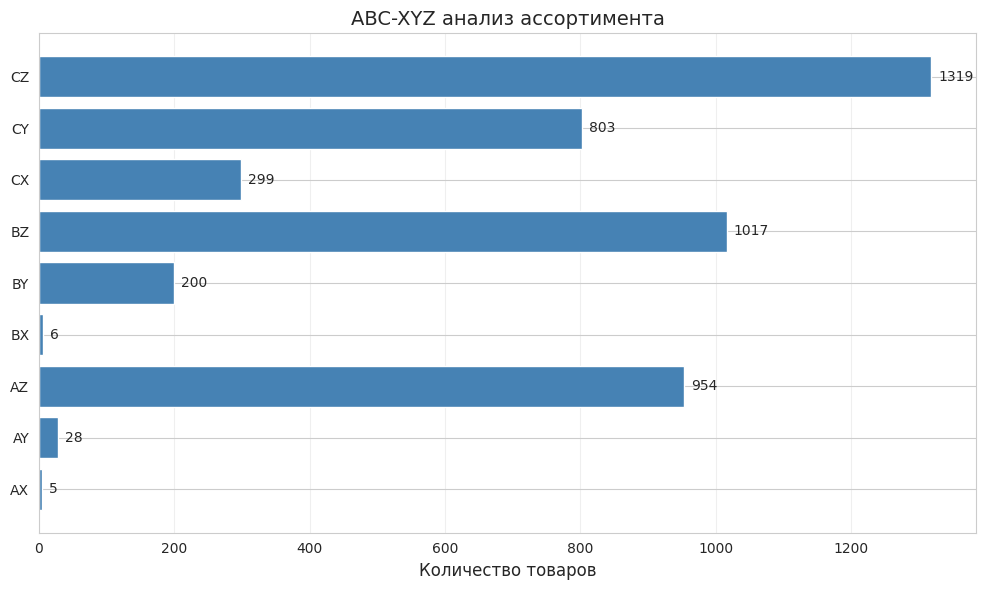

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.barh(abc_xyz_counts.index, abc_xyz_counts.values, color='steelblue')

for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(width + 10, bar.get_y() + bar.get_height()/2,
                 f'{int(width)}', va='center', fontsize=10)

plt.xlabel('Количество товаров', fontsize=12)
plt.title('ABC-XYZ анализ ассортимента', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

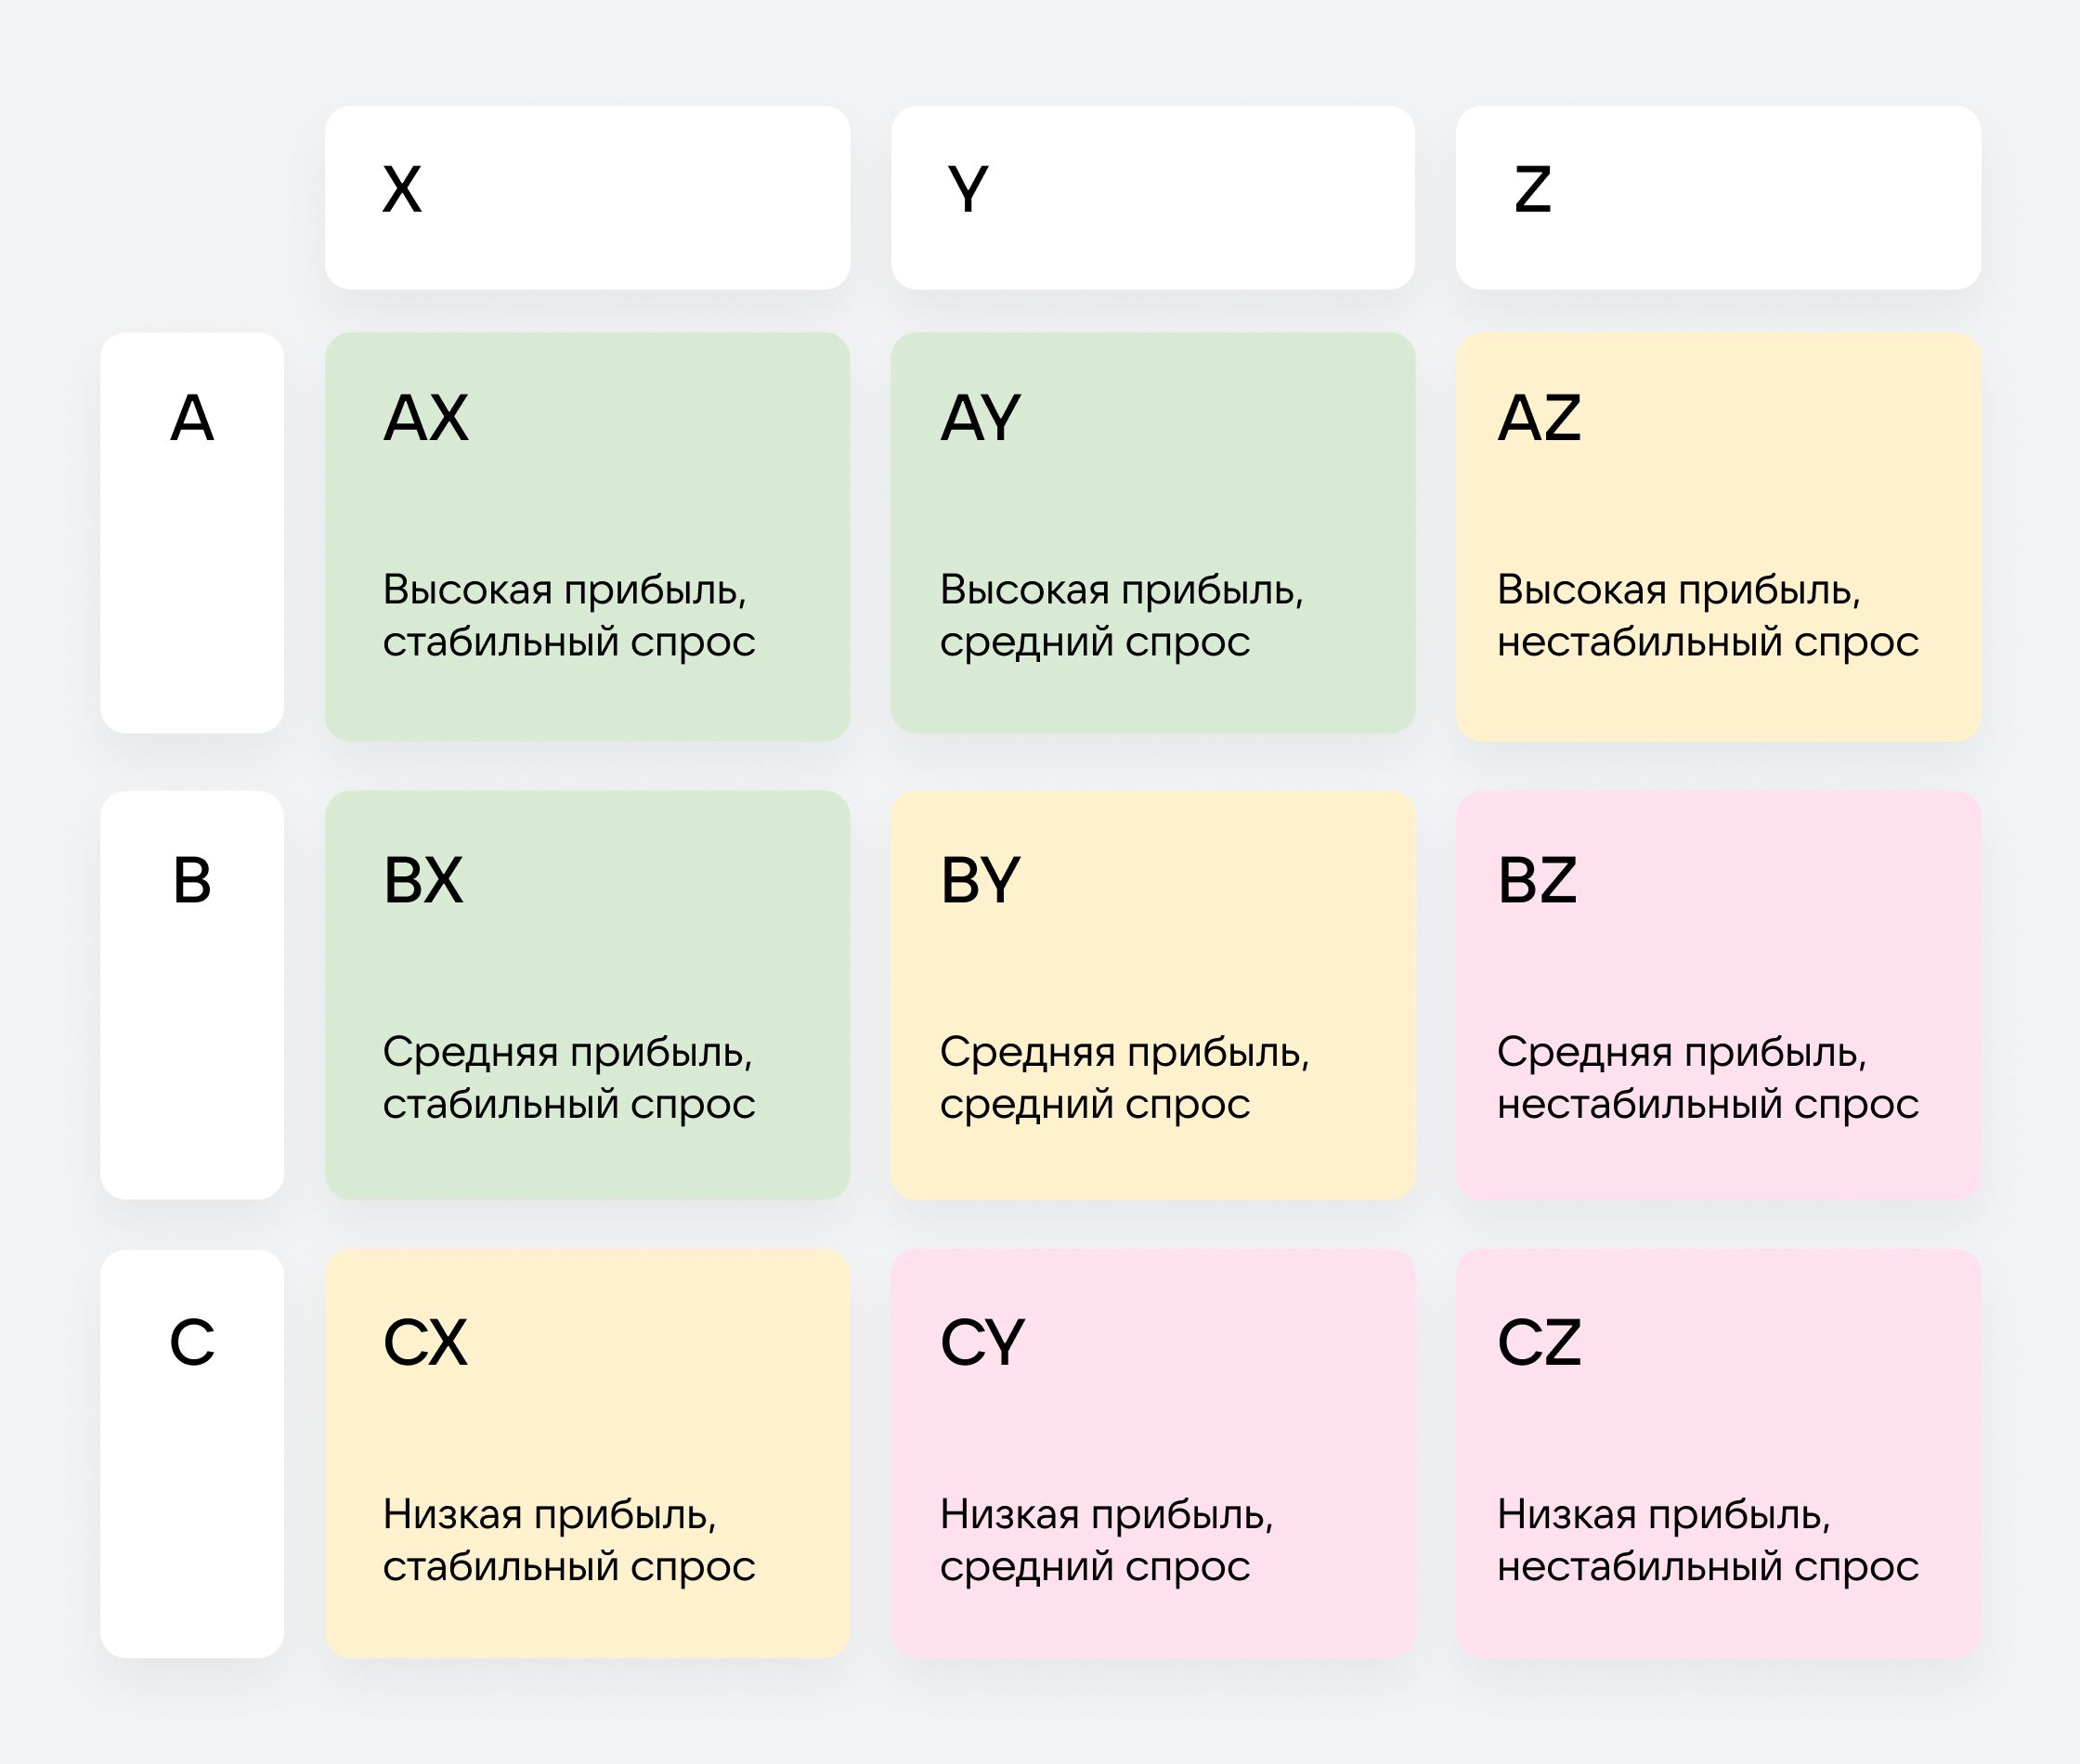

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ ABC-XYZ

In [ ]:
for cat in order:
    count = abc_xyz_counts[cat]
    if count > 0:
        print(f"{cat}: {int(count)} товаров")

AX: 5 товаров
AY: 28 товаров
AZ: 954 товаров
BX: 6 товаров
BY: 200 товаров
BZ: 1017 товаров
CX: 299 товаров
CY: 803 товаров
CZ: 1319 товаров


## Анализ корзин

In [ ]:
!pip install apyori
from apyori import apriori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=57bae3dd72a21714fedcde92c6e0e92e01b12e8902cf41093e9152069177f549
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
df['StockCode_str'] = df['StockCode'].astype(str)

sample_orders = df.groupby('Invoice')['StockCode_str'].apply(list).tolist()

rules = apriori(sample_orders,
                min_support=0.02,
                min_confidence=0.3,
                min_lift=2,
                min_length=2)

# Вывод
rules_list = list(rules)

if len(rules_list) == 0:
    print("Правила не найдены.")
else:
    print(f"Найдено правил: {len(rules_list)}")
    for rule in rules_list[:5]:
        for stat in rule[2]:
            print(f"Товары: {list(stat[0])} -> {list(stat[1])}, Lift = {stat[3]:.2f}")


Найдено правил: 29
Товары: ['20725'] -> ['20726'], Lift = 7.74
Товары: ['20726'] -> ['20725'], Lift = 7.74
Товары: ['20725'] -> ['20727'], Lift = 7.24
Товары: ['20727'] -> ['20725'], Lift = 7.24
Товары: ['20725'] -> ['20728'], Lift = 7.20
Товары: ['20728'] -> ['20725'], Lift = 7.20
Товары: ['20725'] -> ['22382'], Lift = 6.62
Товары: ['22382'] -> ['20725'], Lift = 6.62
Товары: ['20725'] -> ['22383'], Lift = 6.98
Товары: ['22383'] -> ['20725'], Lift = 6.98


Товар 20725 — якорный: его покупка с высокой вероятностью (Lift > 7) ведёт к покупке товаров 20726, 20727, 20728. Рекомендуется размещать эти товары вместе на витрине и предлагать в кросс-продажах.